
# Delivery Time Prediction using Regression Models

This notebook trains and evaluates three regression models for predicting **delivery_time_minutes**:

- Multiple Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  

Workflow:
1. Load dataset
2. Preprocess data
3. Train regression models
4. Evaluate models (MAE, RMSE, R²)
5. Visualize results
6. Feature importance
7. Save trained models for deployment


In [1]:

!pip install pandas scikit-learn matplotlib seaborn joblib openpyxl


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

!pip install scikit-learn==1.5.1

In [3]:

from google.colab import files

uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])

df.head()


Saving dataset (1).xlsx to dataset (1) (1).xlsx


,vegetable_type,shelf_life_days,time_of_day,origin_latitude,origin_longitude,destination_latitude,destination_longitude,route_distance_km,terrain_type,number_of_stops,traffic_density,weather_condition,vehicle_type,delivery_time_minutes
0,Tomatoes,7,Evening,16.414431,120.597061,16.406975,120.592438,1.37,Steep_Slope,2,High,Clear,Truck,49.5
1,Bell Pepper,7,Afternoon,16.417680,120.596164,16.411418,120.595498,0.97,Moderate_Slope,0,Medium,Foggy,Motorcycle,28.7
2,Potatoes,30,Evening,16.459405,120.583741,16.415301,120.589963,6.01,Flat,3,Medium,Rainy,Truck,65.9
3,Cabbage,14,Night,16.462369,120.583862,16.413510,120.588243,6.55,Moderate_Slope,0,Medium,Cloudy,Truck,50.9
4,Tomatoes,7,Night,16.406799,120.602314,16.409533,120.594262,1.10,Flat,0,Medium,Cloudy,Motorcycle,12.3


In [4]:

print("Dataset Shape:", df.shape)
df.info()
df.describe()


Dataset Shape: (5822, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   vegetable_type         5822 non-null   object 
 1   shelf_life_days        5822 non-null   int64  
 2   time_of_day            5822 non-null   object 
 3   origin_latitude        5822 non-null   float64
 4   origin_longitude       5822 non-null   float64
 5   destination_latitude   5822 non-null   float64
 6   destination_longitude  5822 non-null   float64
 7   route_distance_km      5822 non-null   float64
 8   terrain_type           5822 non-null   object 
 9   number_of_stops        5822 non-null   int64  
 10  traffic_density        5822 non-null   object 
 11  weather_condition      5822 non-null   object 
 12  vehicle_type           5822 non-null   object 
 13  delivery_time_minutes  5822 non-null   float64
dtypes: float64(6), int64(2), objec

,shelf_life_days,origin_latitude,origin_longitude,destination_latitude,destination_longitude,route_distance_km,number_of_stops,delivery_time_minutes
count,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.00000
mean,11.379079,16.439716,120.588846,16.412632,120.593486,4.443497,1.498626,46.29854
std,7.028354,0.022952,0.007274,0.003373,0.002517,3.089082,1.116746,16.70189
min,5.000000,16.402139,120.573580,16.404793,120.586849,0.030000,0.000000,2.70000
25%,7.000000,16.414921,120.582756,16.410242,120.591386,1.090000,1.000000,33.00000
50%,10.000000,16.444978,120.587007,16.412675,120.593944,5.160000,1.000000,46.90000
75%,14.000000,16.459235,120.595987,16.415230,120.595511,7.027500,2.000000,59.10000
max,30.000000,16.477083,120.605321,16.420456,120.599582,10.680000,3.000000,95.70000


In [5]:

target = "delivery_time_minutes"

X = df.drop(columns=[target])
y = df[target]

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", list(categorical_cols))
print("Numeric:", list(numeric_cols))


Categorical: ['vegetable_type', 'time_of_day', 'terrain_type', 'traffic_density', 'weather_condition', 'vehicle_type']
Numeric: ['shelf_life_days', 'origin_latitude', 'origin_longitude', 'destination_latitude', 'destination_longitude', 'route_distance_km', 'number_of_stops']


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [7]:

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [8]:

models = {
    "Multiple Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)
}


In [9]:

results = []
predictions_dict = {}
trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    predictions_dict[name] = preds
    trained_models[name] = pipe

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })


In [11]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,1.649138,4.330260,2.080928,0.985246
1,Decision Tree,4.321888,29.453391,5.427098,0.899645
2,Random Forest,3.170143,15.898397,3.987279,0.945830


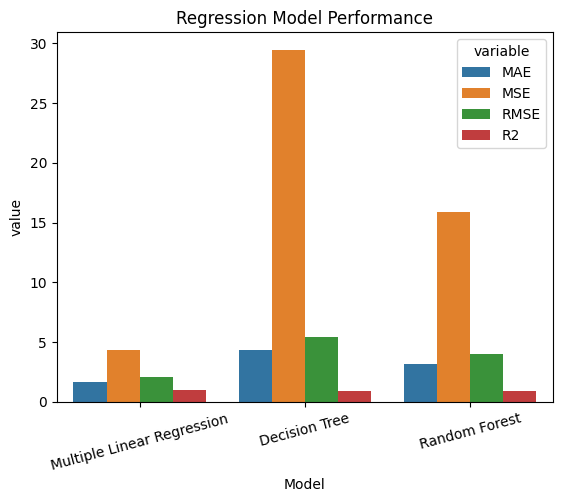

In [12]:

plt.figure()

sns.barplot(
    data=results_df.melt(id_vars="Model"),
    x="Model",
    y="value",
    hue="variable"
)

plt.title("Regression Model Performance")
plt.xticks(rotation=15)

plt.show()


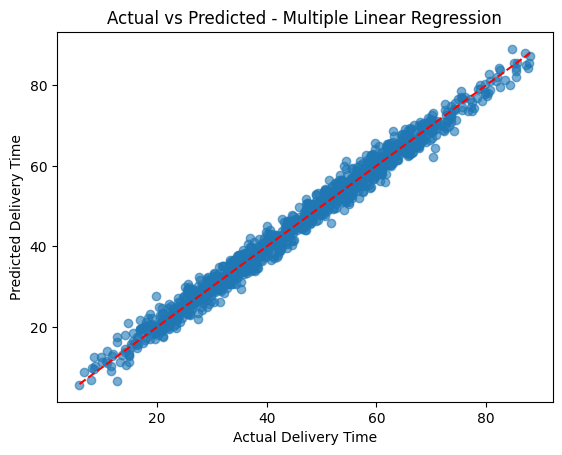

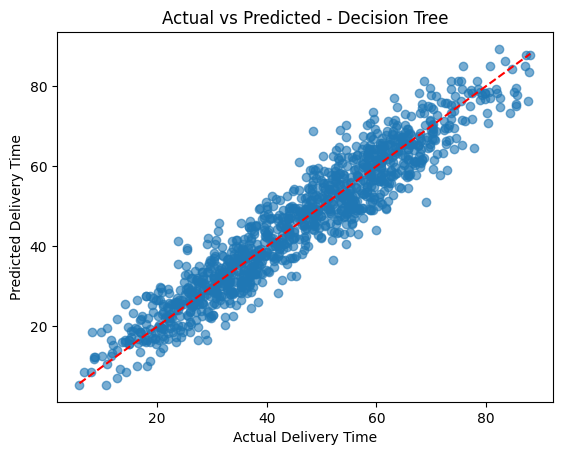

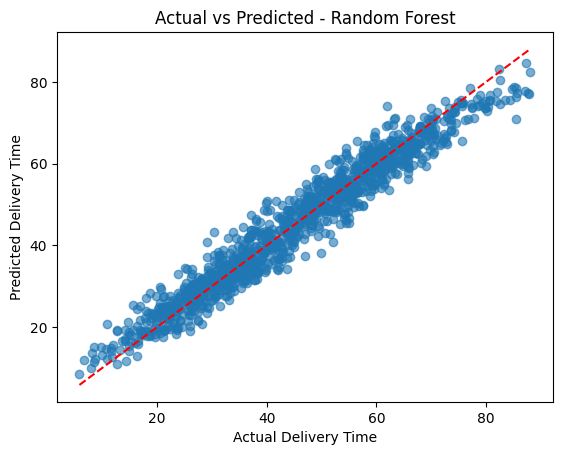

In [13]:

for model_name, preds in predictions_dict.items():

    plt.figure()

    plt.scatter(y_test, preds, alpha=0.6)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    plt.xlabel("Actual Delivery Time")
    plt.ylabel("Predicted Delivery Time")

    plt.title(f"Actual vs Predicted - {model_name}")

    plt.show()


In [14]:

rf_pipeline = trained_models["Random Forest"]

model = rf_pipeline.named_steps["model"]
encoder = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]

encoded_features = encoder.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + list(numeric_cols)

importances = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_df.head(10)


,Feature,Importance
31,route_distance_km,0.711029
32,number_of_stops,0.070544
18,traffic_density_Low,0.034565
25,vehicle_type_Truck,0.028423
16,terrain_type_Steep_Slope,0.022896
27,origin_latitude,0.018971
24,vehicle_type_Motorcycle,0.018600
17,traffic_density_High,0.017240
20,weather_condition_Clear,0.017167
22,weather_condition_Foggy,0.010959


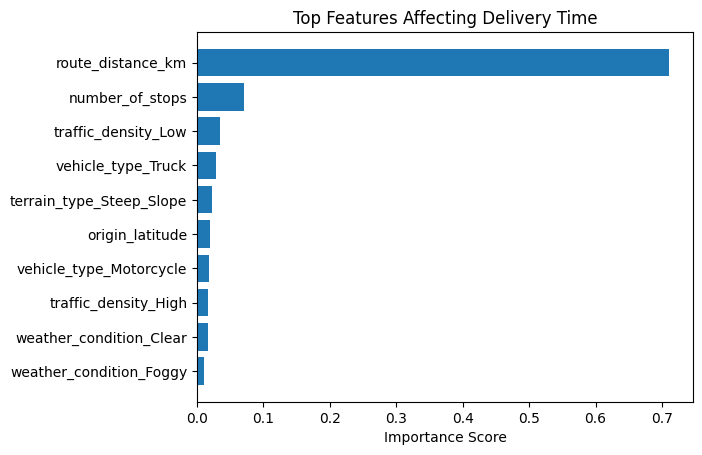

In [15]:

top_features = feature_df.head(10)

plt.figure()

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance Score")
plt.title("Top Features Affecting Delivery Time")

plt.gca().invert_yaxis()

plt.show()


In [16]:

joblib.dump(trained_models["Multiple Linear Regression"], "linear_regression_model.pkl")
joblib.dump(trained_models["Decision Tree"], "decision_tree_model.pkl")
joblib.dump(trained_models["Random Forest"], "random_forest_model.pkl")

print("Models saved successfully")


Models saved successfully


In [17]:

from google.colab import files

files.download("linear_regression_model.pkl")
files.download("decision_tree_model.pkl")
files.download("random_forest_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>